# 04 — Visualization & Report

**Goal:** Turn statistical analysis into clear visualisations, and
write up important findings for the README / portfolio project.

Figures are saved to `../reports/figures/` so they can be embedded directly in the
README or a portfolio site.


In [1]:
import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import load_data as ld
import stats_utils as su

sns.set_style("whitegrid")
FIG_DIR = "../reports/figures"

con = ld.get_connection()
DATA_DIR = "../data/raw"

snapshot = pd.read_parquet("../data/processed/snapshot_dataset.parquet")
feature_cols = [c for c in snapshot.columns if c.startswith("smart_") and c.endswith("_raw")]
mw_results = su.mann_whitney_by_attribute(snapshot, feature_cols)
mw_results

,attribute,u_stat,p_value,effect_size_rank_biserial,healthy_median,failed_median
0,smart_5_raw,173176590.5,0.000000e+00,0.6059,0.0,9.0
1,smart_197_raw,176189534.0,0.000000e+00,0.6339,0.0,4.0
2,smart_198_raw,151981829.5,0.000000e+00,0.4094,0.0,0.0
3,smart_9_raw,142648758.0,7.779036e-61,0.3228,27446.0,41391.0
4,smart_4_raw,139317335.5,3.152435e-50,0.2919,10.0,13.0
5,smart_12_raw,134479991.0,1.790119e-36,0.2471,10.0,13.0
6,smart_193_raw,124399750.0,4.915689e-15,0.1536,896.0,1842.0
7,smart_192_raw,121615584.5,6.981984e-11,0.1278,11.0,25.0
8,smart_1_raw,119260271.5,2.040911e-10,0.1059,0.0,0.0
9,smart_7_raw,116650641.0,9.157196e-07,0.0817,0.0,0.0


## 1. Failure Rate by Drive Model

Recomputed straight from the raw data via DuckDB's `failure_summary`, which is not from the snapshot.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

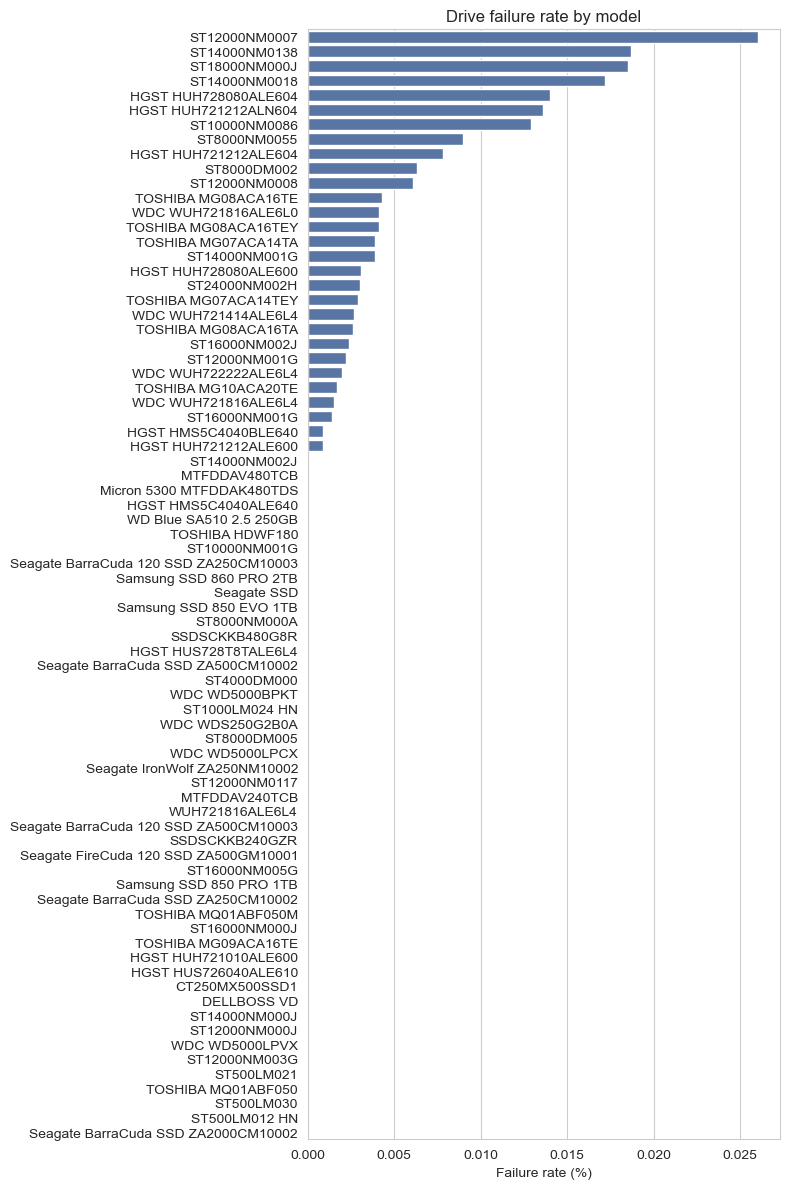

In [4]:
fail_summary = ld.failure_summary(con, DATA_DIR).sort_values("failure_rate_pct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 12))
sns.barplot(data=fail_summary, y="model", x="failure_rate_pct", ax=ax, color="#4C72B0")
ax.set_xlabel("Failure rate (%)")
ax.set_ylabel("")
ax.set_title("Drive failure rate by model")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/failure_rate_by_model.png", dpi=150)
plt.show()

## 2. SMART Attribute Distributions: failed vs. healthy

For each attribute that came out significant in statistical analysis, a boxplot comparing the two
groups.

Plotting: ['smart_5_raw', 'smart_197_raw', 'smart_198_raw', 'smart_9_raw', 'smart_4_raw', 'smart_12_raw', 'smart_193_raw', 'smart_192_raw', 'smart_1_raw', 'smart_7_raw', 'smart_194_raw', 'smart_3_raw']


C:\Users\User\AppData\Local\Temp\ipykernel_24128\773689499.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y=attr, ax=ax, palette={"Healthy": "#4C72B0", "Failed": "#C44E52"})
C:\Users\User\AppData\Local\Temp\ipykernel_24128\773689499.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y=attr, ax=ax, palette={"Healthy": "#4C72B0", "Failed": "#C44E52"})
C:\Users\User\AppData\Local\Temp\ipykernel_24128\773689499.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", 

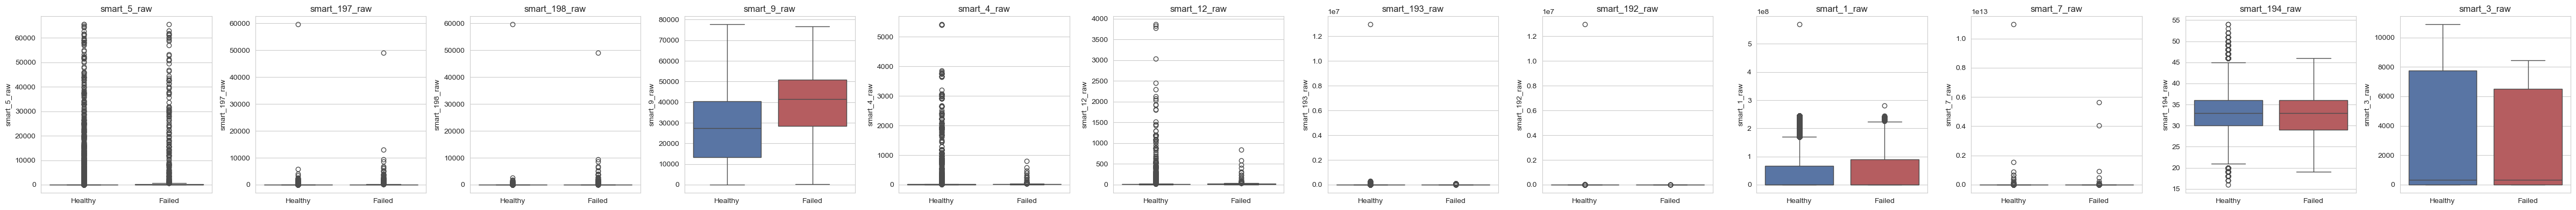

In [4]:
significant_attrs = mw_results.loc[mw_results["p_value"] < 0.05, "attribute"].tolist()
print("Plotting:", significant_attrs)

n = len(significant_attrs)
fig, axes = plt.subplots(1, max(n, 1), figsize=(4 * max(n, 1), 4))
if n == 1:
    axes = [axes]

for ax, attr in zip(axes, significant_attrs):
    plot_df = snapshot[[attr, "label"]].copy()
    plot_df["group"] = plot_df["label"].map({0: "Healthy", 1: "Failed"})
    sns.boxplot(data=plot_df, x="group", y=attr, ax=ax, palette={"Healthy": "#4C72B0", "Failed": "#C44E52"})
    ax.set_title(attr)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/smart_attribute_boxplots.png", dpi=150)
plt.show()

## 3. Correlation Heatmap

Visual companion to statistical analysis' `high_correlation_pairs` used to spot clusters of redundant attributes.

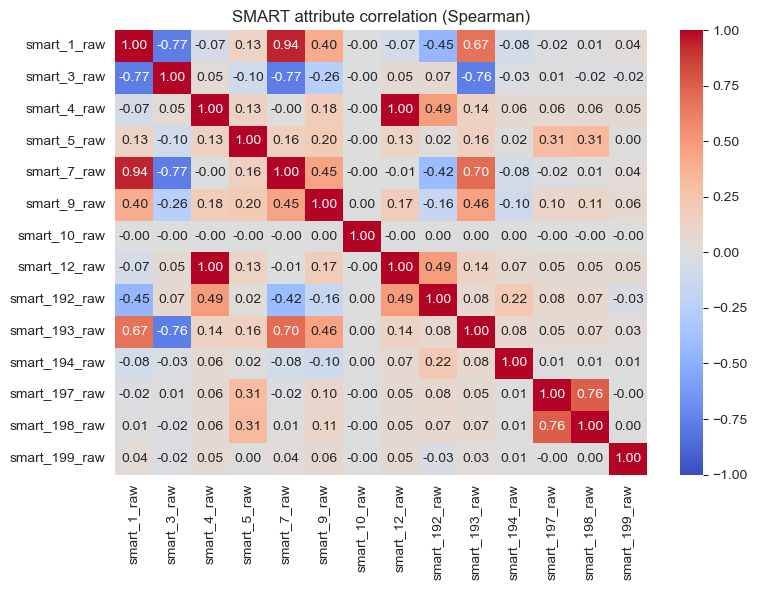

In [5]:
corr = su.correlation_matrix(snapshot, feature_cols)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("SMART attribute correlation (Spearman)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

## 4. Effect Size Summary Chart

A single chart ranking attributes by effect size (not just p-value) to reinforce the idea 
that statistical significance and practical importance are not the same thing.

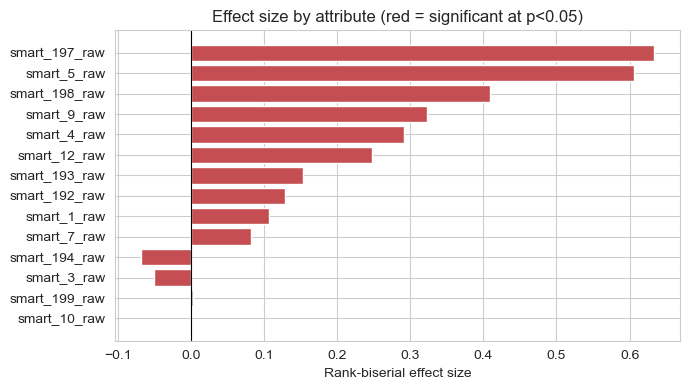

In [6]:
plot_df = mw_results.copy().sort_values("effect_size_rank_biserial", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#C44E52" if p < 0.05 else "#999999" for p in plot_df["p_value"]]
ax.barh(plot_df["attribute"], plot_df["effect_size_rank_biserial"], color=colors)
ax.set_xlabel("Rank-biserial effect size")
ax.set_title("Effect size by attribute (red = significant at p<0.05)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/effect_size_summary.png", dpi=150)
plt.show()

## 5. Written findings (draft for README)

_Fill in the bracketed numbers once this notebook is rerun against the real Q1 2025
dataset — the structure below is ready to copy into the project README as-is._

### Business framing
This project investigates which SMART (Self-Monitoring, Analysis, and Reporting
Technology) attributes are most associated with hard drive failure from Backblaze's
public Q1 2025 dataset. 

### Data & Limitations
- Single quarter of data (Q1 2025, 90 days)
- Analysis restricted to **11 drive models** with ≥30 failure events in the quarter,
  covering **82.2%** of all recorded failures — smaller models are not statistically
  significant to analyse individually
- Snapshot approach: one reading per drive (day before failure, or last day of quarter
  for healthy drives) rather than the full daily time series, to keep the unit of
  analysis at the drive level

### Methodology
- **DuckDB** for all raw-data querying (schema exploration, failure-rate summaries,
  building the labelled snapshot dataset) — chosen because the full dataset doesn't fit
  comfortably in memory, and DuckDB queries the CSV folder directly without a separate
  load step
- **Mann-Whitney U tests** (not t-tests) per SMART attribute, since these attributes are
  right-skewed and the failed/healthy groups are very unequal in size, plus a
  rank-biserial effect size alongside each p-value
- **Spearman correlation** to check for redundant/multicollinear attributes
- A simple, non-tuned **logistic regression** as a sanity check for separable signal
  (ROC-AUC, not accuracy, given the class imbalance) — descriptive only, not a
  predictive model

### Findings
- Attributes most associated with failure: **smart_197_raw, smart_5_raw**. Note that this pair is not highly correlated.
- Attribute **smart_197_raw** showed the largest effect size (rank-biserial = **0.6339**), 
  with a median of **4** in failed drives vs. **0** in healthy drives                                                         
- Attribute **smart_194_raw, smart_3_raw** were considered statistically significant 
  but had small effect sizes
- Attribute pairs such as **smart_1_raw** and **smart_7_raw** were highly correlated, with both of them having 
  p-value < 0.05 and similar effect sizes. 
- This may indicate that they were **redundant** factors, 
  and their significance did not reflect separable factors.
- The logistic regression sanity check achieved an ROC-AUC of **0.886**, suggesting
  meaningful separable signal using only these attributes

### Next steps
- This project sets up a natural extension into predictive modelling: survival analysis
  (time-to-failure) or a tuned classification model, planned as the Month 4 ML project
- Additional quarters of data would allow tracking drive age effects, which this single
  quarter can't capture


## Week 4 checklist

- [x] Failure rate by model (bar chart)
- [x] SMART attribute distributions, failed vs. healthy (boxplots)
- [x] Correlation heatmap
- [x] Effect size summary chart
- [x] Draft written findings section, ready to copy into README
- [ ] Rerun this entire notebook against the real Q1 2025 dataset and fill in the
      bracketed numbers in Section 5
- [ ] Copy the finished "Findings" section into the project README
- [ ] Review all four figures in `reports/figures/` for the portfolio site / GitHub README
